In [4]:
image="Screenshot 2026-04-06 at 2.51.12 PM.png"

In [5]:
!pip install -qqq ultralytics

In [6]:
from ultralytics import YOLO
yolo_model = YOLO('yolov8n.pt')



100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6.25M/6.25M [00:00<00:00, 7.58MB/s]


In [8]:
 import matplotlib.pyplot as plt
import matplotlib.patches as patches

def display_image_with_boxes(image, detections):
    fig, ax = plt.subplots(1, figsize=(12, 9))
    ax.imshow(image)

    for det in detections:
        box = det['box']
        label = det['label']
        score = det['score']

        rect = patches.Rectangle(
            (box['xmin'], box['ymin']),
            box['xmax'] - box['xmin'],
            box['ymax'] - box['ymin'],
            linewidth=2,
            edgecolor='r',
            facecolor='none'
        )

        ax.add_patch(rect)

        plt.text(
            box['xmin'], box['ymin'] - 10,
            f"{label}: {score:.2f}",
            color='white',
            fontsize=12,
            bbox=dict(facecolor='red', alpha=0.7)
        )

    ax.axis('off')
    plt.show()


0: 448x640 1 person, 1 bicycle, 80.1ms
Speed: 3.6ms preprocess, 80.1ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
  - Label: person, Score: 0.88, Box: {'xmin': 519.34619140625, 'ymin': 6.578984260559082, 'xmax': 787.6331787109375, 'ymax': 410.3184814453125}
  - Label: bicycle, Score: 0.84, Box: {'xmin': 526.6743774414062, 'ymin': 242.15882873535156, 'xmax': 882.1712036132812, 'ymax': 550.373779296875}


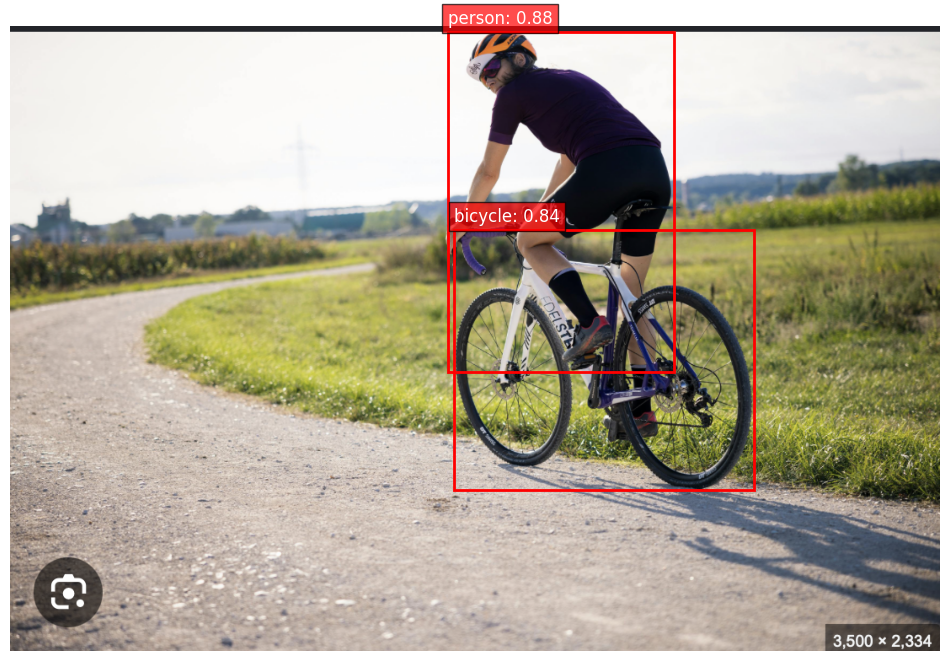

In [11]:
from PIL import Image
import cv2
import numpy as np

image_path = 'Screenshot 2026-04-06 at 2.51.12 PM.png'

cv_image = cv2.imread(image_path)

if cv_image is None:
    raise FileNotFoundError(f"Image not found or unable to load: {image_path}")

rgb_image = cv2.cvtColor(cv_image, cv2.COLOR_BGR2RGB)

image = Image.fromarray(rgb_image)

yolo_results = yolo_model(image)

yolo_detections = []
for r in yolo_results:
    for box in r.boxes:
        label_id = int(box.cls)
        label = yolo_model.names[label_id] 
        score = float(box.conf) 

        xmin, ymin, xmax, ymax = map(float, box.xyxy[0])

        if label in ['bicycle', 'person']:
            yolo_detections.append({
                'label': label,
                'score': score,
                'box': {'xmin': xmin, 'ymin': ymin, 'xmax': xmax, 'ymax': ymax}
            })

for det in yolo_detections:
    print(f"  - Label: {det['label']}, Score: {det['score']:.2f}, Box: {det['box']}")

display_image_with_boxes(image, yolo_detections)
